# Includings

In [ ]:
import os
import pandas as pd
import numpy as np

# Functions

## To average

In [2]:
def average_replicate_matrices(data_dict, matrix_dir, load_func=pd.read_csv):
    """
    Load and average coverage matrices (forward & reverse) for each experiment.
    
    Args:
        data_dict: nested dict {experiment: {replicate: [reverse_path, forward_path]}}
        matrix_dir: path to directory containing coverage matrix files
        load_func: function to load matrix file (default: pd.read_csv)
    
    Returns:
        dict_mat: {experiment: {'forward': DataFrame, 'reverse': DataFrame}}
    """
    dict_mat = {}

    for experiment, replicates in data_dict.items():
        forward_matrices = []
        reverse_matrices = []

        print(experiment, replicates)

        for rep_name, files in replicates.items():

            
            # Identify which file is forward/reverse
            forward_file = next(f for f in files if "forward" in f)
            reverse_file = next(f for f in files if "reverse" in f)

            # Load the matrices
            forward_path = os.path.join(matrix_dir, forward_file)
            reverse_path = os.path.join(matrix_dir, reverse_file)

            fwd_df = load_func(forward_path, index_col=0)
            rev_df = load_func(reverse_path, index_col=0)

            forward_matrices.append(fwd_df)
            reverse_matrices.append(rev_df)

        # Compute mean across replicates (aligned by index/columns)
        forward_avg = sum(forward_matrices) / len(forward_matrices)
        forward_avg.to_csv(f'avgforwardmatrix{experiment}.csv')
        reverse_avg = sum(reverse_matrices) / len(reverse_matrices)
        reverse_avg.to_csv(f'avgreversematrix{experiment}.csv')

        dict_mat[experiment] = {
            "forward": forward_avg,
            "reverse": reverse_avg
        }

    return dict_mat

## Coverage

In [ ]:
import matplotlib.cm as cm

def _to_numeric_index(xindex):
    """Safely convert an Index of positions to float array (NaNs if uncastable)."""
    # Works for numeric, stringified numeric, Int64Index, RangeIndex, etc.
    return pd.to_numeric(pd.Index(xindex), errors='coerce').to_numpy()

def plot_overlayed_coverage_with_background_subtraction(cumulative_dict, experiment_order=None):
    if experiment_order is None:
        experiment_order = list(cumulative_dict.keys())

    plt.figure(figsize=(10, 6))
    cmap = cm.get_cmap('viridis', len(experiment_order))
    color_cycle = [cmap(i) for i in range(len(experiment_order))]

    after_subtraction = []
    bgsub_dict = {}

    for i, experiment in enumerate(experiment_order):
        # Drops the last column if it’s metadata, as in your code
        forward_df = cumulative_dict[experiment]['forward'].iloc[:, :-1]
        reverse_df = cumulative_dict[experiment]['reverse'].iloc[:, :-1]

        
        reverse_bg = reverse_df.iloc[:, 300:399].mean(axis=1, skipna=True)
        #print(reverse_bg)
        #print(reverse_bg.mean())
        reverse_df_bgsub = reverse_df.sub(reverse_bg, axis=0) #.clip(lower=0)
        reverse_df_bgsub = reverse_df_bgsub #.clip(lower=0)

        #reverse_df_bgsub.iloc[:, 300:399] = 0.0

        after_subtraction.append(reverse_df_bgsub)

        check_rev = reverse_df_bgsub.iloc[:, 300:399].mean(axis=1)
        #print(check_rev)  # mean ≈ 0, small numerical noise
        #print(reverse_df_bgsub.iloc[:, -200:-150].mean(axis=0).mean()) #mean after averaging over all hotspots, still 0 is expected
        
        
        forward_bg = forward_df.iloc[:, 0:100].mean(axis=1, skipna=True)
        #print(forward_bg)
        forward_df_bgsub = forward_df.sub(forward_bg, axis=0) #.clip(lower=0)
        forward_df_bgsub = forward_df_bgsub #.clip(lower=0)
        #forward_df_bgsub.iloc[:, 0:100] = 0.0

        bgsub_dict[experiment] = {
            "forward": forward_df_bgsub,
            "reverse": reverse_df_bgsub
        }

        reverse_mean = reverse_df_bgsub.mean(axis=0) #.rolling(window=10, center=True).mean()

        #print(reverse_mean.iloc[-200:-150].mean())

        forward_mean = forward_df_bgsub.mean(axis=0) #.rolling(window=10, center=True).mean()   #.iloc[:1, :]

        # Convert indices (positions) to numeric arrays
        x_rev = _to_numeric_index(reverse_mean.index)
        x_fwd = _to_numeric_index(forward_mean.index)

        color = color_cycle[i]

        # Plot with corrected labels: reverse=solid, forward=dashed
        plt.plot(x_rev, reverse_mean, label=f"{experiment} (forward)", linestyle='-',  color=color)
        plt.plot(x_fwd, forward_mean, label=f"{experiment} (reverse)", linestyle='--', color=color)

    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()
    
    return bgsub_dict

## Cumulative

In [ ]:
def compute_cumulative_dict(dict_mat, output_dir,th=1):  
    """
    Compute and return cumulative matrices per experiment.
    Also saves forward and reverse CSVs to disk.

    Args:
        dict_mat: dict of {experiment: {'forward': DataFrame, 'reverse': DataFrame}}
        output_dir: directory to save CSVs

    Returns:
        cumulative_dict: same structure as dict_mat but with cumulative values
    """
    os.makedirs(output_dir, exist_ok=True)
    cumulative_dict = {}

    bad_indexes = []

    for experiment, matrices in dict_mat.items():
        forward = matrices['forward']#.iloc[:, :-1]  # remove dummy column if present
        reverse = matrices['reverse']#.iloc[:, :-1]

        fwd_cum = pd.DataFrame(index=forward.index, columns=forward.columns)
        rev_cum = pd.DataFrame(index=reverse.index, columns=reverse.columns)

        for idx in forward.index:
            # Forward: right to left
            f_row = forward.loc[idx].astype(float).fillna(0.0)#.clip(lower=0)   #Ensures monotonicity of Cumulative curve
            fwd_row = f_row.cumsum()
            #fwd_row = forward.loc[idx][::-1].cumsum()[::-1]
            total_fwd = fwd_row.iloc[-1]
            if total_fwd<th:
                bad_indexes.append(idx)
            fwd_row /= total_fwd if total_fwd != 0 else 1
            fwd_cum.loc[idx] = fwd_row

            # Reverse: left to right
            #rev_row = reverse.loc[idx].cumsum()
            r_row = reverse.loc[idx].astype(float).fillna(0.0)#.clip(lower=0)
            rev_row = r_row[::-1].cumsum()[::-1]
            total_rev = rev_row.iloc[0]
            if total_rev<th:
                bad_indexes.append(idx)
            rev_row /= total_rev if total_rev != 0 else 1
            rev_cum.loc[idx] = rev_row

        
        # Store in new dict
        cumulative_dict[experiment] = {
            'forward': fwd_cum,
            'reverse': rev_cum
        }

    bad_indexes = list(set(bad_indexes))
    print(len(bad_indexes))
    
    
    for experiment, matrices in dict_mat.items():
        # Save CSVs

        # Store in new dict
        cumulative_dict[experiment]['forward'] = cumulative_dict[experiment]['forward'].drop(index=bad_indexes) 
        cumulative_dict[experiment]['reverse'] = cumulative_dict[experiment]['reverse'].drop(index=bad_indexes)

        fwd_path = os.path.join(output_dir, f"{experiment}_forward_cumulative.csv")
        rev_path = os.path.join(output_dir, f"{experiment}_reverse_cumulative.csv")
        cumulative_dict[experiment]['forward'].to_csv(fwd_path)
        cumulative_dict[experiment]['reverse'].to_csv(rev_path)
        print(f"[✓] Saved: {fwd_path}")
        print(f"[✓] Saved: {rev_path}")


    return cumulative_dict


In [ ]:
import matplotlib.cm as cm

def plot_overlayed_cumulative(cumulative_dict, experiment_order=None):
    """
    Overlay mean cumulative plots for forward and reverse strands across experiments.
    - Reverse strand: solid lines
    - Forward strand: dashed lines
    - Same color used for both lines of each experiment

    Args:
        cumulative_dict: dict of {experiment: {'forward': DataFrame, 'reverse': DataFrame}}
        experiment_order: Optional list to enforce consistent time ordering
    """
    if experiment_order is None:
        experiment_order = list(cumulative_dict.keys())

    plt.figure(figsize=(10, 6))

    # Set color map with consistent spacing
    cmap = cm.get_cmap('viridis', len(experiment_order))
    color_cycle = [cmap(i) for i in range(len(experiment_order))]

    for i, experiment in enumerate(experiment_order):
        forward_df = cumulative_dict[experiment]['forward']
        reverse_df = cumulative_dict[experiment]['reverse']

        forward_mean = forward_df.mean(axis=0, skipna=True)
        reverse_mean = reverse_df.mean(axis=0, skipna=True)
        x_vals = forward_mean.index.astype(float)

        color = color_cycle[i]

        # Reverse = solid, Forward = dashed
        plt.plot(x_vals, reverse_mean.values, label=f"{experiment} (forward)", linestyle='-', color=color)
        plt.plot(x_vals, forward_mean.values, label=f"{experiment} (reverse)", linestyle='--', color=color)

    plt.title("Mean Cumulative Signal (Forward & Reverse)")
    plt.xlabel("Position")
    plt.ylabel("Normalized Cumulative Signal")
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.axhline(1, color='black', linestyle='--', linewidth=1)
    plt.legend()
    plt.grid()
    plt.yticks([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])
    plt.tight_layout()
    plt.show()

## Crossings

In [4]:
def compute_crossings(dict_mat):
    """
    Compute horizontal and vertical crossings for each region and experiment.
    
    For each row, crossings are defined as:
    - Horizontal: column index where forward and reverse are equal, or mean(j, j+1) if a crossing occurs between.
    - Vertical: value of the forward/reverse matrix at that crossing.

    Returns:
        DataFrame with columns: horizontal_<experiment>, vertical_<experiment>
    """
    all_crossings = {}

    for experiment, matrices in dict_mat.items():
        fwd_df = matrices['forward']
        rev_df = matrices['reverse']

        fwd = fwd_df.to_numpy()
        rev = rev_df.to_numpy()
        index = fwd_df.index
        cols = np.array(fwd_df.columns, dtype=float)

        horizontal_crossings = []
        vertical_crossings = []

        for i in range(fwd.shape[0]):
            crossing_points = []
            crossing_values = []

            for j in range(fwd.shape[1] - 1):
                # Exact crossing
                if fwd[i, j] == rev[i, j]:
                    crossing_points.append(cols[j])
                    crossing_values.append(fwd[i, j])

                # Crossover between columns
                elif (fwd[i, j] < rev[i, j] and fwd[i, j + 1] > rev[i, j + 1]) or \
                     (fwd[i, j] > rev[i, j] and fwd[i, j + 1] < rev[i, j + 1]):
                    # Use average position between columns
                    crossing_pos = (cols[j] + cols[j + 1]) / 2
                    crossing_val = np.mean([fwd[i, j], fwd[i, j + 1]])
                    crossing_points.append(crossing_pos)
                    crossing_values.append(crossing_val)

            # Mean of all crossings in the row
            horizontal_crossings.append(np.mean(crossing_points) if crossing_points else np.nan)
            vertical_crossings.append(np.mean(crossing_values) if crossing_values else np.nan)

        # Store in output dict
        all_crossings[f'horizontal_{experiment}'] = horizontal_crossings
        all_crossings[f'vertical_{experiment}'] = vertical_crossings

    return pd.DataFrame(all_crossings, index=index)

In [5]:
from scipy.stats import spearmanr
def compute_spearman_per_region(crossings_df, experiment_order):
    """
    Compute Spearman correlation per region for horizontal and vertical crossings.
    
    Returns:
        DataFrame with columns: region, type, spearman_corr, p_value
    """
    timepoints = list(range(len(experiment_order)))
    results = []

    for crossing_type in ['horizontal', 'vertical']:
        cols = [f"{crossing_type}_{exp}" for exp in experiment_order]
        sub_df = crossings_df[cols]

        for idx in sub_df.index:
            values = sub_df.loc[idx].values.astype(float)
            mask = ~np.isnan(values)
            if mask.sum() < 2:
                corr, pval = np.nan, np.nan
            else:
                corr, pval = spearmanr(np.array(timepoints)[mask], values[mask])
            results.append({
                'region': idx,
                'type': crossing_type,
                'spearman_corr': corr,
                'p_value': pval
            })

    return pd.DataFrame(results)


import matplotlib.pyplot as plt
import seaborn as sns

def plot_significant_spearman_histogram(spearman_df):
    """
    Plot histogram + KDE of Spearman ρ values (p < 0.05),
    separately for horizontal and vertical.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for ax, ctype in zip(axes, ['horizontal', 'vertical']):
        subset = spearman_df[
            (spearman_df['type'] == ctype) &
            (spearman_df['p_value'] < 0.05) &
            (~spearman_df['spearman_corr'].isna())
        ]

        if not subset.empty:
            sns.histplot(
                subset['spearman_corr'],
                bins=20,
                kde=True,
                stat="count",
                edgecolor='black',
                alpha=0.6,
                ax=ax
            )
        else:
            ax.text(0.5, 0.5, "No significant\ncorrelations", ha='center', va='center', fontsize=12)
            ax.set_xlim(-1, 1)

        ax.set_title(f"{ctype.capitalize()} crossings (p < 0.05)")
        ax.set_xlabel("Spearman ρ")
        ax.set_ylabel("Count")
        ax.axvline(0, color='black', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.show()


In [6]:
def plot_spearman_histograms(spearman_df):
    """
    Plot histograms and KDEs of Spearman ρ values for:
    - All correlations
    - Only those with p < 0.05
    Separately for horizontal and vertical.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

    for i, ctype in enumerate(['horizontal', 'vertical']):
        # All correlations
        all_subset = spearman_df[
            (spearman_df['type'] == ctype) &
            (~spearman_df['spearman_corr'].isna())
        ]
        sns.histplot(
            all_subset['spearman_corr'],
            bins=20,
            kde=True,
            stat="count",
            edgecolor='black',
            alpha=0.6,
            ax=axes[0, i]
        )
        axes[0, i].set_title(f"All {ctype} Spearman ρ")
        axes[0, i].axvline(0, color='black', linestyle='--')

        # Significant only (p < 0.05)
        sig_subset = all_subset[all_subset['p_value'] < 0.05]
        if not sig_subset.empty:
            sns.histplot(
                sig_subset['spearman_corr'],
                bins=20,
                kde=True,
                stat="count",
                edgecolor='black',
                alpha=0.6,
                ax=axes[1, i]
            )
        else:
            axes[1, i].text(0.5, 0.5, "No significant\ncorrelations", ha='center', va='center', fontsize=12)
            axes[1, i].set_xlim(-1, 1)

        axes[1, i].set_title(f"Significant {ctype} Spearman ρ (p < 0.05)")
        axes[1, i].axvline(0, color='black', linestyle='--')

        # Set axis labels
        for row in [0, 1]:
            axes[row, i].set_xlabel("Spearman ρ")
            axes[row, i].set_ylabel("Count")

    plt.tight_layout()
    plt.show()


In [7]:
def plot_crossing_trends_scatter(crossings_df, experiment_order):
    """
    Plot mean ± SEM, median, and individual data points (scatter) for
    horizontal and vertical crossing values over time.

    Args:
        crossings_df: DataFrame with columns like horizontal_<exp>, vertical_<exp>
        experiment_order: list of experiment names in temporal order
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

    for ax, crossing_type in zip(axes, ['horizontal', 'vertical']):
        means, medians, sems = [], [], []

        for i, exp in enumerate(experiment_order):
            col = f"{crossing_type}_{exp}"
            values = crossings_df[col].astype(float)
            means.append(values.mean(skipna=True))
            medians.append(values.median(skipna=True))
            sems.append(values.sem(skipna=True))

            # Scatter: add jittered x-values for visual separation
            y_vals = values.dropna()
            jittered_x = np.random.normal(loc=i, scale=0.1, size=len(y_vals))
            ax.scatter(jittered_x, y_vals, alpha=0.4, color='gray', s=15, label='Region values' if i == 0 else None)

        x = np.arange(len(experiment_order))
        means = np.array(means)
        medians = np.array(medians)
        sems = np.array(sems)

        ax.plot(x, means, color ='darkblue', label='Mean', marker='o', linestyle='-', linewidth=2)
        #ax.fill_between(x, means - sems, means + sems, alpha=0.3, label='± SEM')
        ax.plot(x, medians, color = 'darkred', label='Median', marker='s', linestyle='--', linewidth=2)

        ax.set_xticks(x)
        ax.set_xticklabels(experiment_order, rotation=45)
        ax.set_title(f"{crossing_type.capitalize()} Crossings Over Time")
        ax.set_ylabel("Crossing Value")
        ax.set_xlabel("Timecourse")
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.legend()

    plt.tight_layout()
    plt.show()

## Percentiles

In [10]:
def get_percentile_position_dfs(cumulative_dict, percentile_low=0.1, percentile_high=0.9):
    """
    Compute x-positions where cumulative signal crosses low/high percentiles.
    Returns two wide-format DataFrames (forward & reverse) with one row per region,
    and two columns per experiment: <experiment>_10th and <experiment>_90th.

    Args:
        cumulative_dict: dict of {experiment: {'forward': df, 'reverse': df}}
        percentile_low: e.g. 0.1
        percentile_high: e.g. 0.9

    Returns:
        forward_df_wide, reverse_df_wide: wide-format DataFrames
    """
    forward_10th = {}
    forward_90th = {}
    reverse_10th = {}
    reverse_90th = {}

    for experiment, strands in cumulative_dict.items():
        fwd_df = strands['forward']
        rev_df = strands['reverse']
        x_vals = fwd_df.columns.astype(float)

        f10 = []
        f90 = []
        r10 = []
        r90 = []
        idx = []

        for region in fwd_df.index:
            idx.append(region)

            try:
                # Forward (right to left)
                fwd = fwd_df.loc[region].astype(float).values
                fwd_x = x_vals
                #fwd_x = x_vals[::-1]
                fwd_y = fwd
                x10_fwd = np.interp(percentile_low, fwd_y, fwd_x)
                x90_fwd = np.interp(percentile_high, fwd_y, fwd_x)
            except:
                x10_fwd = x90_fwd = np.nan
            f10.append(x10_fwd)
            f90.append(x90_fwd)

            try:
                # Reverse (left to right)
                rev = rev_df.loc[region].astype(float).values[::-1]
                rev_x = x_vals[::-1]
                x10_rev = np.interp(percentile_low, rev, rev_x)
                x90_rev = np.interp(percentile_high, rev, rev_x)
            except:
                x10_rev = x90_rev = np.nan
            r10.append(x10_rev)
            r90.append(x90_rev)

        forward_10th[f"{experiment}_10th"] = pd.Series(f10, index=idx)
        forward_90th[f"{experiment}_90th"] = pd.Series(f90, index=idx)
        reverse_10th[f"{experiment}_10th"] = pd.Series(r10, index=idx)
        reverse_90th[f"{experiment}_90th"] = pd.Series(r90, index=idx)

    # Combine columns
    forward_df = pd.concat([pd.DataFrame(forward_10th), pd.DataFrame(forward_90th)], axis=1)
    reverse_df = pd.concat([pd.DataFrame(reverse_10th), pd.DataFrame(reverse_90th)], axis=1)

    # Optional: sort columns
    forward_df = forward_df.reindex(sorted(forward_df.columns), axis=1)
    reverse_df = reverse_df.reindex(sorted(reverse_df.columns), axis=1)

    return forward_df, reverse_df

In [36]:
def plot_percentile_trends_scatter(percentile_df, experiment_order):
    """
    Plot mean ± SEM, median, and individual data points (scatter) for
    10th and 90th percentile positions over time.

    Args:
        percentile_df: DataFrame with columns like <exp>_10th and <exp>_90th
        experiment_order: list of experiment names in temporal order (no suffix)
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
    percentile_types = ['10th', '90th']
    colors = {'10th': 'royalblue', '90th': 'crimson'}

    for ax, perc_type in zip(axes, percentile_types):
        means, medians, sems = [], [], []

        for i, exp in enumerate(experiment_order):
            col = f"{exp}_{perc_type}"
            values = percentile_df[col].astype(float)
            means.append(values.mean(skipna=True))
            medians.append(values.median(skipna=True))
            sems.append(values.sem(skipna=True))

            # Scatter: region-wise values with jitter
            y_vals = values.dropna()
            jittered_x = np.random.normal(loc=i, scale=0.1, size=len(y_vals))
            ax.scatter(jittered_x, y_vals, alpha=0.4, color='gray', s=15, label='Region values' if i == 0 else None)

        x = np.arange(len(experiment_order))
        means = np.array(means)
        medians = np.array(medians)
        sems = np.array(sems)

        ax.plot(x, means, color=colors[perc_type], label='Mean', marker='o', linestyle='-', linewidth=2)
        # Optional SEM ribbon
        # ax.fill_between(x, means - sems, means + sems, alpha=0.2, color=colors[perc_type], label='± SEM')
        ax.plot(x, medians, color='black', label='Median', marker='s', linestyle='--', linewidth=2)

        ax.set_xticks(x)
        ax.set_xticklabels(experiment_order, rotation=45)
        ax.set_title(f"{perc_type} Percentile Positions Over Time")
        ax.set_ylabel("Genomic Position")
        ax.set_xlabel("Timecourse")
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.legend()

    plt.tight_layout()
    plt.show()


# Analysis

## Load matrices 

In [32]:
base_fold_ivan = '/Users/ivandt/Documents/Work/MeiosisProject'
base_fold_harini = '/home/h/Harini.Maruthi/Data'
base_fold_Arka = '' ### Arka put here your base folder
base_fold = base_fold_ivan
fold_matrix = base_fold + '/Data/Matrices'

fold_matrix_RPA = fold_matrix+'/RPA'
os.chdir(fold_matrix_RPA)
files_matrix_RPA = [file for file in os.listdir() if '.csv' in file and 'RPA' in file and 'avg' not in file]

types_RPA = np.unique([file.split('_')[0] for file in files_matrix_RPA])
samples_RPA = np.unique([file.split('_')[1]+'_'+file.split('_')[2] for file in files_matrix_RPA])

file_dict_RPA = {}                 
for t in types_RPA:
    file_dict_RPA[t] = {}
    files_RPA_t = [file for file in files_matrix_RPA if t in file]
    for sample in samples_RPA:
        file_dict_RPA[t][sample] = [file for file in files_RPA_t if sample in file]


fold_matrix_DMC1 = fold_matrix+'/DMC1'
os.chdir(fold_matrix_DMC1)
files_matrix_DMC1 = [file for file in os.listdir() if '.csv' in file and 'DMC1' in file and 'avg' not in file]

types_DMC1 = np.unique([file.split('_')[0] for file in files_matrix_DMC1])
samples_DMC1 = np.unique([file.split('_')[1]+'_'+file.split('_')[2] for file in files_matrix_DMC1])

file_dict_DMC1 = {}                
for t in types_DMC1:
    file_dict_DMC1[t] = {}
    files_DMC1_t = [file for file in files_matrix_DMC1 if t in file]
    for sample in samples_DMC1:
        file_dict_DMC1[t][sample] = [file for file in files_DMC1_t if sample in file]

## Average replicates

In [33]:
dir_DMC1 = '/Users/ivandt/Documents/Work/MeiosisProject/Data/Matrices/DMC1'
dict_mat_DMC1 = average_replicate_matrices(file_dict_DMC1, dir_DMC1)  #Returns all matrices after averaging across replicates R1, R2 and R3, organized in a dictionary structure

dir_RPA = '/Users/ivandt/Documents/Work/MeiosisProject/Data/Matrices/RPA'
dict_mat_RPA = average_replicate_matrices(file_dict_RPA, dir_RPA)  #Returns all matrices after averaging across replicates R1, R2 and R3, organized in a dictionary structure



matrixDMC1-WT-164 {'R1_T1.sorted.unparsed': ['matrixDMC1-WT-164_R1_T1.sorted.unparsed_type1.reverse.bw.csv', 'matrixDMC1-WT-164_R1_T1.sorted.unparsed_type1.forward.bw.csv'], 'R2_T1.sorted.unparsed': ['matrixDMC1-WT-164_R2_T1.sorted.unparsed_type1.forward.bw.csv', 'matrixDMC1-WT-164_R2_T1.sorted.unparsed_type1.reverse.bw.csv'], 'R3_T1.sorted.unparsed': ['matrixDMC1-WT-164_R3_T1.sorted.unparsed_type1.forward.bw.csv', 'matrixDMC1-WT-164_R3_T1.sorted.unparsed_type1.reverse.bw.csv']}
matrixDMC1-WT-176 {'R1_T1.sorted.unparsed': ['matrixDMC1-WT-176_R1_T1.sorted.unparsed_type1.reverse.bw.csv', 'matrixDMC1-WT-176_R1_T1.sorted.unparsed_type1.forward.bw.csv'], 'R2_T1.sorted.unparsed': ['matrixDMC1-WT-176_R2_T1.sorted.unparsed_type1.forward.bw.csv', 'matrixDMC1-WT-176_R2_T1.sorted.unparsed_type1.reverse.bw.csv'], 'R3_T1.sorted.unparsed': ['matrixDMC1-WT-176_R3_T1.sorted.unparsed_type1.forward.bw.csv', 'matrixDMC1-WT-176_R3_T1.sorted.unparsed_type1.reverse.bw.csv']}
matrixDMC1-WT-190 {'R1_T1.sorted

## 3' end coverage plots

/var/folders/ms/r_1pjk5j4hz92q31p5bcg02h0000gp/T/ipykernel_11098/3757017784.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', len(experiment_order))


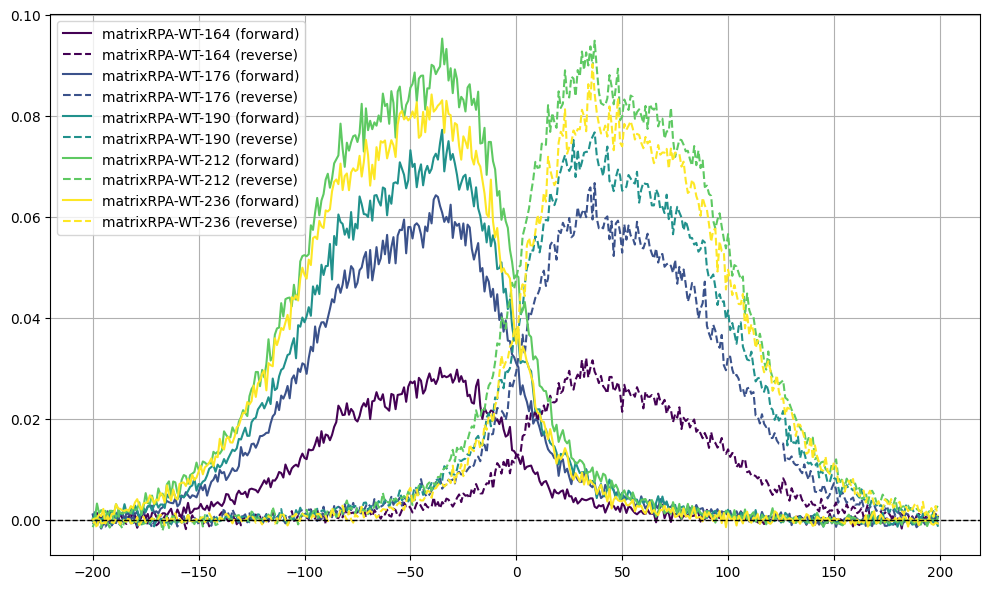

/var/folders/ms/r_1pjk5j4hz92q31p5bcg02h0000gp/T/ipykernel_11098/3757017784.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', len(experiment_order))


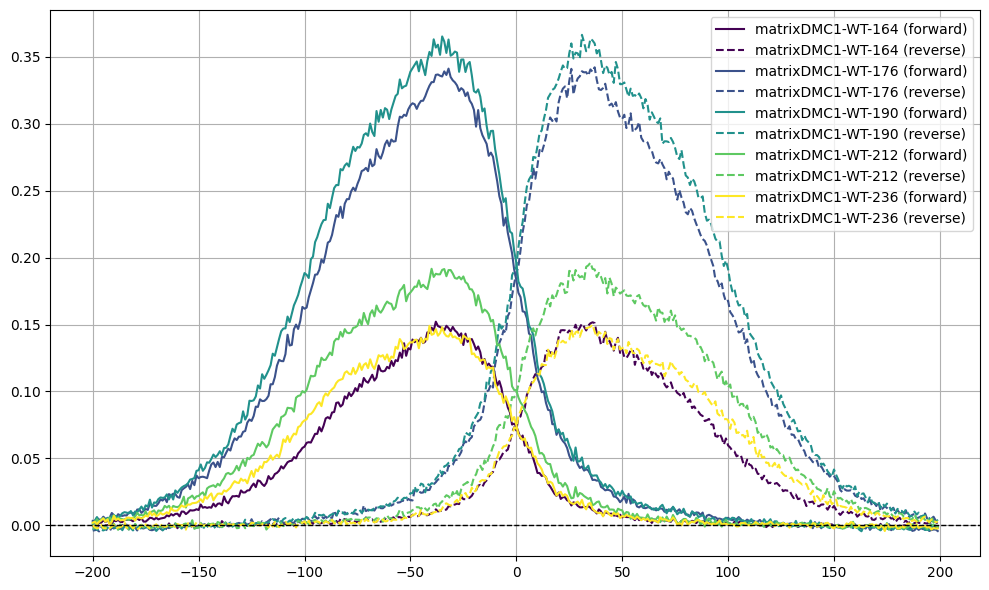

In [34]:
experiment_order_DMC1 = ['matrixDMC1-WT-164', 'matrixDMC1-WT-176', 'matrixDMC1-WT-190', 'matrixDMC1-WT-212', 'matrixDMC1-WT-236']
experiment_order_RPA = ['matrixRPA-WT-164', 'matrixRPA-WT-176', 'matrixRPA-WT-190', 'matrixRPA-WT-212', 'matrixRPA-WT-236']

bgsub_RPA = plot_overlayed_coverage_with_background_subtraction(dict_mat_RPA, experiment_order_RPA)
bgsub_DMC1 = plot_overlayed_coverage_with_background_subtraction(dict_mat_DMC1, experiment_order_DMC1)

## Tests for cumulative (Rubbish)

In [43]:
bgsub_DMC1['matrixDMC1-WT-164']['forward'].loc['chr1:59358990-59359564']

-200   -0.01
-199   -0.01
-198   -0.01
-197   -0.01
-196   -0.01
        ... 
195    -0.01
196    -0.01
197    -0.01
198    -0.01
199    -0.01
Name: chr1:59358990-59359564, Length: 400, dtype: float64

In [ ]:
forward = bgsub_RPA['matrixRPA-WT-164']['forward']
fwd_cum = pd.DataFrame(index=forward.index, columns=forward.columns)

tots = []
avgs = []

for idx in forward.index:
        # Forward: right to left
        f_row = forward.loc[idx].astype(float).fillna(0.0)#.clip(lower=0)   #Ensures monotonicity of Cumulative curve
        fwd_row = f_row.cumsum()
        #fwd_row = forward.loc[idx][::-1].cumsum()[::-1]
        total_fwd = fwd_row.iloc[-1]
        tots.append(total_fwd)
        fwd_row /= total_fwd if total_fwd != 0 else 1
        fwd_cum.loc[idx] = fwd_row
tots = np.array(tots)
forward.loc['chrX:88485240-88485848']
#fwd_cum

-200   -0.003333
-199   -0.003333
-198   -0.003333
-197   -0.003333
-196   -0.003333
          ...   
195    -0.003333
196    -0.003333
197    -0.003333
198    -0.003333
199    -0.003333
Name: chrX:88485240-88485848, Length: 400, dtype: float64

In [76]:
forward.loc['chrX:88485240-88485848'].sum()

-5.551115123125783e-16

(array([2.584e+03, 5.120e+02, 1.410e+02, 6.200e+01, 2.900e+01, 1.200e+01,
        8.000e+00, 3.000e+00, 3.000e+00, 2.000e+00]),
 array([ 1.        ,  5.41666667,  9.83333333, 14.25      , 18.66666667,
        23.08333333, 27.5       , 31.91666667, 36.33333333, 40.75      ,
        45.16666667]),
 <BarContainer object of 10 artists>)

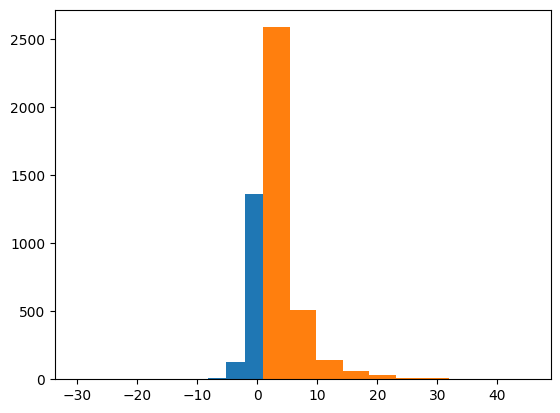

In [78]:
plt.hist(tots[tots<1])
plt.hist(tots[tots>=1])

In [77]:
len(tots[tots<1])

1495

In [69]:
forward = bgsub_RPA['matrixRPA-WT-164']['forward']
fwd_cum = pd.DataFrame(index=forward.index, columns=forward.columns)
for idx in ['chrX:88485240-88485848']:#forward.index:
        # Forward: right to left
        f_row = forward.loc[idx].astype(float).fillna(0.0)#.clip(lower=0)   #Ensures monotonicity of Cumulative curve
        fwd_row = f_row.cumsum()
        #fwd_row = forward.loc[idx][::-1].cumsum()[::-1]
        total_fwd = fwd_row.iloc[-1]
        #fwd_row /= total_fwd if total_fwd != 0 else 1
        #fwd_cum.loc[idx] = fwd_row

#forward.loc['chrX:88485240-88485848']
#fwd_cum

In [70]:
fwd_row

-200   -3.333333e-03
-199   -6.666667e-03
-198   -1.000000e-02
-197   -1.333333e-02
-196   -1.666667e-02
            ...     
195     1.333333e-02
196     1.000000e-02
197     6.666667e-03
198     3.333333e-03
199    -8.786374e-16
Name: chrX:88485240-88485848, Length: 400, dtype: float64

In [67]:
forward.index

Index(['chr1:59358990-59359564', 'chr1:86088048-86088880',
       'chr1:58419902-58420598', 'chr1:154652805-154653558',
       'chr1:67961706-67963003', 'chr1:163310429-163311659',
       'chr1:86217767-86218772', 'chr1:105417587-105418145',
       'chr1:177024690-177025645', 'chr1:151269488-151270256',
       ...
       'chrX:169969974-169970740', 'chrX:66509463-66510083',
       'chrX:163906422-163907214', 'chrX:6011745-6013065',
       'chrX:46744732-46745686', 'chrX:169971967-169972919',
       'chrX:111598605-111599624', 'chrX:112877308-112877827',
       'chrX:88485240-88485848', 'chrX:152926272-152927072'],
      dtype='object', length=4851)

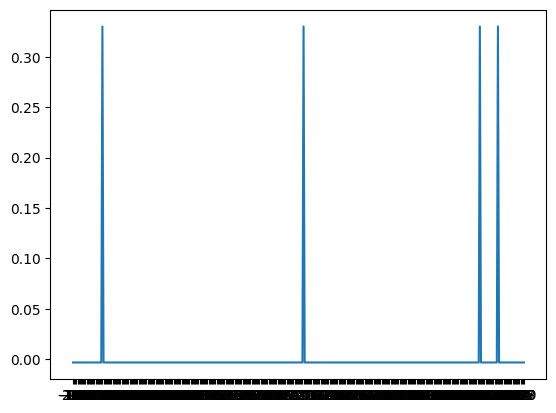

In [65]:
plt.plot(forward.loc['chrX:88485240-88485848'])

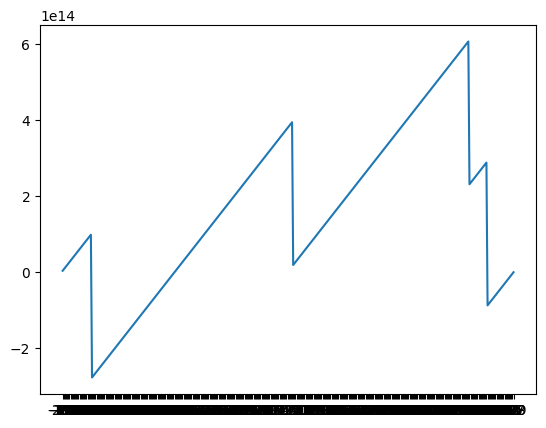

In [66]:
plt.plot(fwd_cum.loc['chrX:88485240-88485848'])


In [61]:
fwd_cum.mean(axis=0)

-200    112644702075.853699
-199    254215464546.727997
-198     615326089503.53064
-197    689000754567.395386
-196    949125818205.057129
               ...         
195    -108934833269.487289
196      -99562586269.26944
197      -14551104340.00548
198        -1131401553.1161
199                0.999175
Length: 400, dtype: object

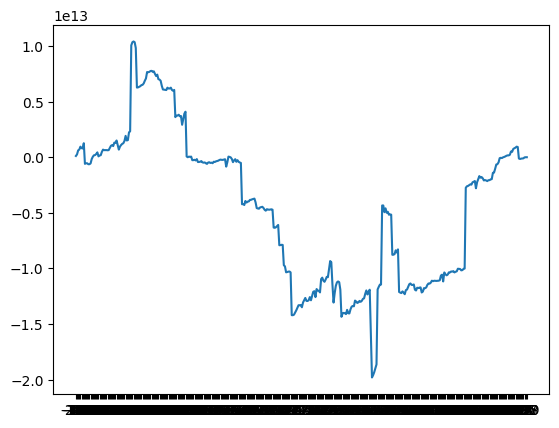

In [59]:
plt.plot(fwd_cum.mean(axis=0))

## Cumulatives

In [85]:
output_dir = base_fold + '/Data/Matrices/DMC1_cumulative_csvs_bgsub'
cumulative_DMC1_bgsub = compute_cumulative_dict(bgsub_DMC1, output_dir)

output_dir = base_fold + '/Data/Matrices/RPA_cumulative_csvs_bgsub'
cumulative_RPA_bgsub = compute_cumulative_dict(bgsub_RPA, output_dir)

2802
[✓] Saved: /Users/ivandt/Documents/Work/MeiosisProject/Data/Matrices/RPA_cumulative_csvs_bgsub/matrixRPA-WT-164_forward_cumulative.csv
[✓] Saved: /Users/ivandt/Documents/Work/MeiosisProject/Data/Matrices/RPA_cumulative_csvs_bgsub/matrixRPA-WT-164_reverse_cumulative.csv
[✓] Saved: /Users/ivandt/Documents/Work/MeiosisProject/Data/Matrices/RPA_cumulative_csvs_bgsub/matrixRPA-WT-176_forward_cumulative.csv
[✓] Saved: /Users/ivandt/Documents/Work/MeiosisProject/Data/Matrices/RPA_cumulative_csvs_bgsub/matrixRPA-WT-176_reverse_cumulative.csv
[✓] Saved: /Users/ivandt/Documents/Work/MeiosisProject/Data/Matrices/RPA_cumulative_csvs_bgsub/matrixRPA-WT-190_forward_cumulative.csv
[✓] Saved: /Users/ivandt/Documents/Work/MeiosisProject/Data/Matrices/RPA_cumulative_csvs_bgsub/matrixRPA-WT-190_reverse_cumulative.csv
[✓] Saved: /Users/ivandt/Documents/Work/MeiosisProject/Data/Matrices/RPA_cumulative_csvs_bgsub/matrixRPA-WT-212_forward_cumulative.csv
[✓] Saved: /Users/ivandt/Documents/Work/MeiosisPro

/var/folders/ms/r_1pjk5j4hz92q31p5bcg02h0000gp/T/ipykernel_11098/1903435293.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', len(experiment_order))


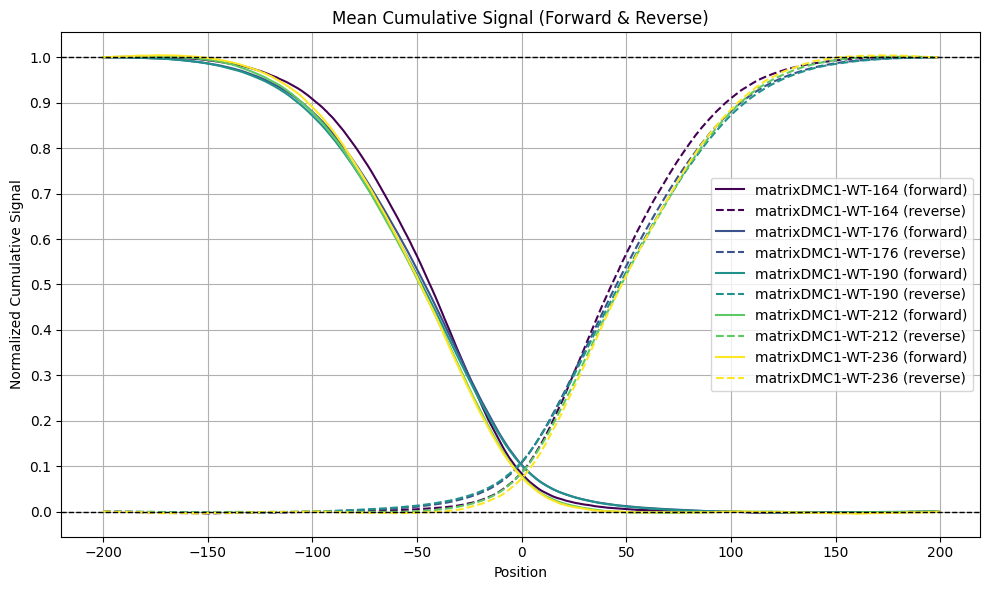

/var/folders/ms/r_1pjk5j4hz92q31p5bcg02h0000gp/T/ipykernel_11098/1903435293.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', len(experiment_order))


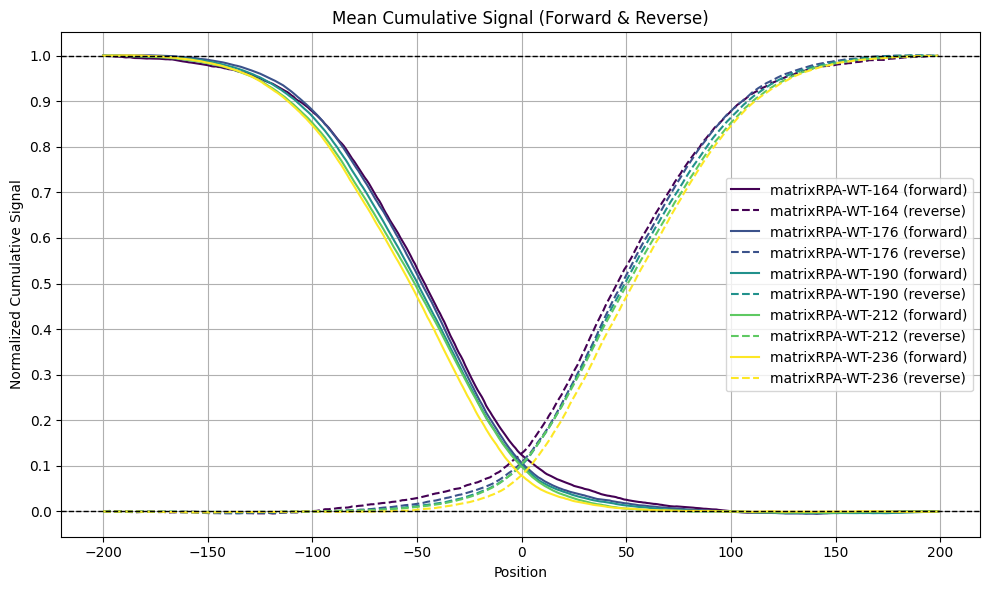

In [89]:
plot_overlayed_cumulative(cumulative_DMC1_bgsub, experiment_order_DMC1)
plot_overlayed_cumulative(cumulative_RPA_bgsub, experiment_order_RPA)

In [90]:
#crossings_df_RPA = compute_crossings(cumulative_dict_RPA)
crossings_df_DMC1 = compute_crossings(cumulative_DMC1_bgsub)
crossings_df_RPA = compute_crossings(cumulative_RPA_bgsub)

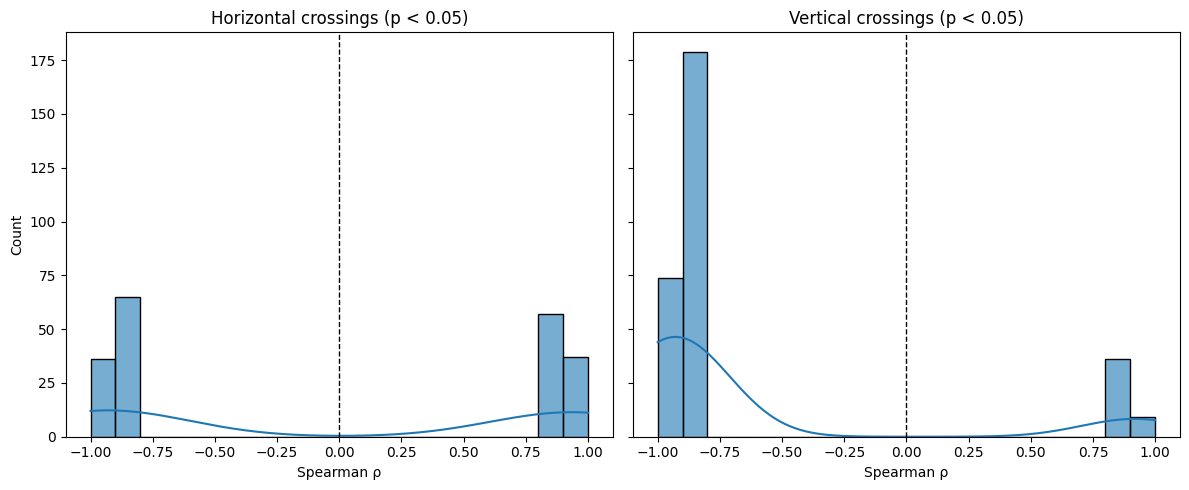

In [93]:
spearman_df_RPA = compute_spearman_per_region(crossings_df_RPA, experiment_order_RPA)
plot_significant_spearman_histogram(spearman_df_RPA)


#this is a test for RPA. do the same for DMC1 as necessary

In [61]:
crossings_df_bgsub_rpa = compute_crossings(cumulative_rpa_bgsub)
crossings_df_bgsub_dmc1 = compute_crossings(cumulative_dmc1_bgsub)

In [ ]:
# Compute Spearman correlations
spearman_df_bgsub_rpa = compute_spearman_per_region(crossings_df_bgsub_rpa, experiment_order)

# Plot histogram of significant correlations
plot_significant_spearman_histogram(spearman_df_bgsub_rpa)

In [ ]:
# Compute Spearman correlations
spearman_df_bgsub_dmc1 = compute_spearman_per_region(crossings_df_bgsub_dmc1, experiment_order_dmc1)

# Plot histogram of significant correlations
plot_significant_spearman_histogram(spearman_df_bgsub_dmc1)

In [ ]:
plot_crossing_trends_scatter(crossings_df_bgsub_rpa, experiment_order)
plot_crossing_trends_scatter(crossings_df_bgsub_dmc1, experiment_order_dmc1)

In [ ]:
fwd_percentile_df_rpa_bgsub, rev_percentile_df_rpa_bgsub = get_percentile_position_dfs(cumulative_rpa_bgsub)

In [ ]:
fwd_percentile_df_dmc1_bgsub, rev_percentile_df_dmc1_bgsub = get_percentile_position_dfs(cumulative_dmc1_bgsub)

In [ ]:
plot_percentile_trends_scatter(rev_percentile_df_rpa_bgsub, experiment_order)
plot_percentile_trends_scatter(fwd_percentile_df_rpa_bgsub, experiment_order)

In [ ]:
plot_percentile_trends_scatter(rev_percentile_df_dmc1_bgsub, experiment_order_dmc1)
plot_percentile_trends_scatter(fwd_percentile_df_dmc1_bgsub, experiment_order_dmc1)